In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
df = pd.read_csv(r"../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [51]:
#chrun distribution

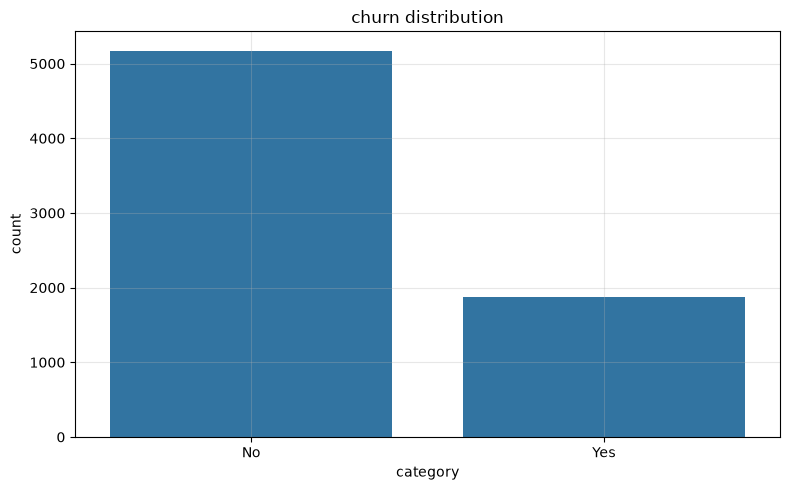

In [52]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x="Churn")
plt.xlabel("category")
plt.ylabel("count")
plt.title("churn distribution")
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()

In [53]:
#numeric distribution

In [54]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

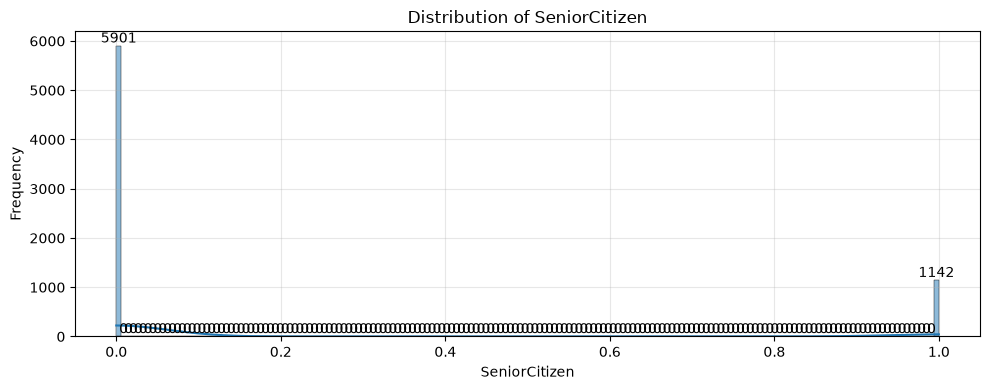

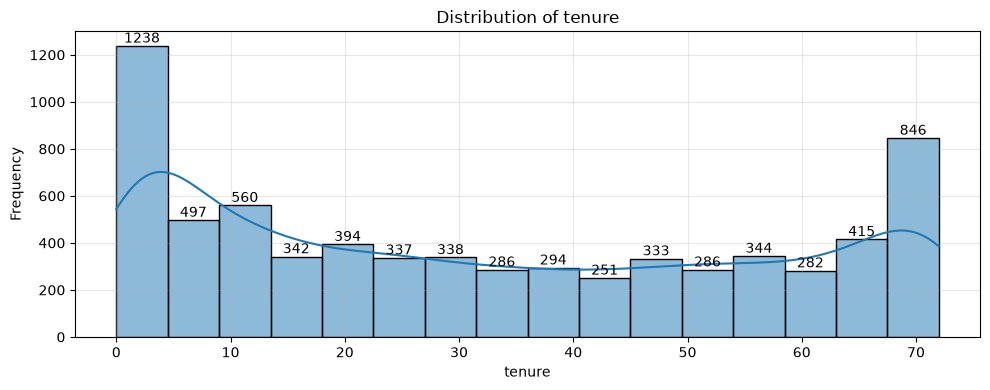

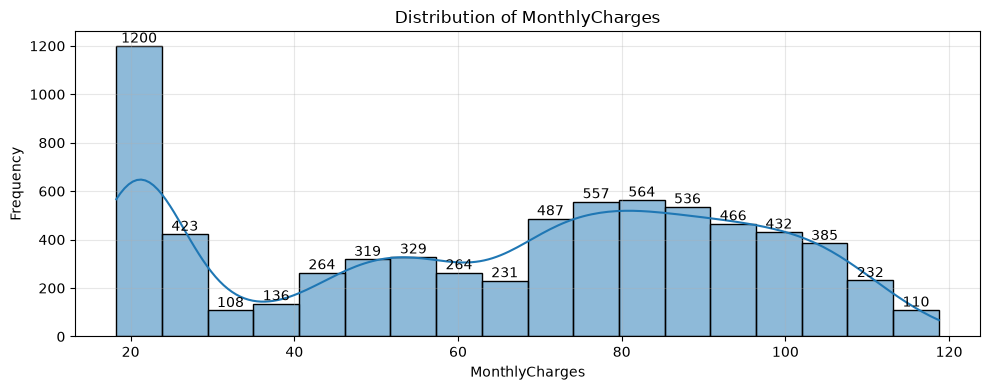

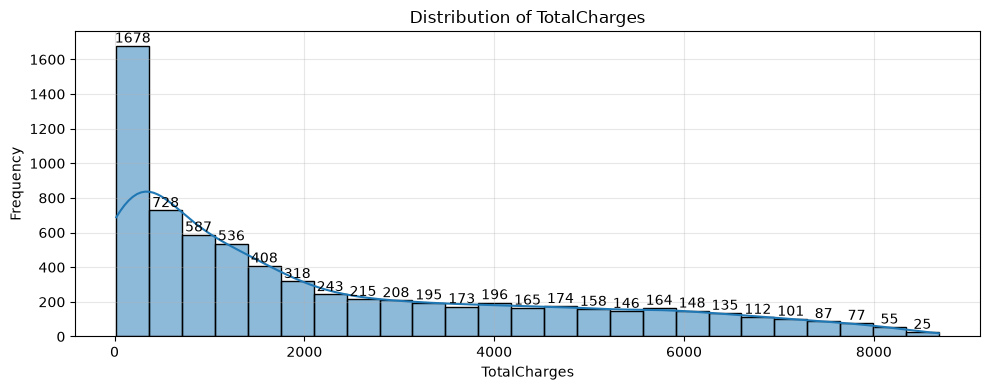

In [55]:
numerical_cols = ['SeniorCitizen','tenure', 'MonthlyCharges', 'TotalCharges']

for col in numerical_cols:
    plt.figure(figsize=(10, 4))
    ax=sns.histplot(data=df, x=col, kde=True)
    for container in ax.containers:
        ax.bar_label(container)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.grid(alpha=0.3)
    plt.show()

In [56]:
#cat col distribution

C:\Users\rizwa\AppData\Local\Temp\ipykernel_3356\483885445.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = df.select_dtypes(include=object).columns.to_list()


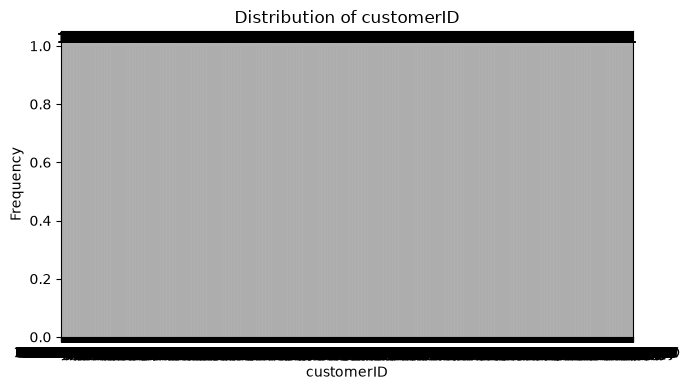

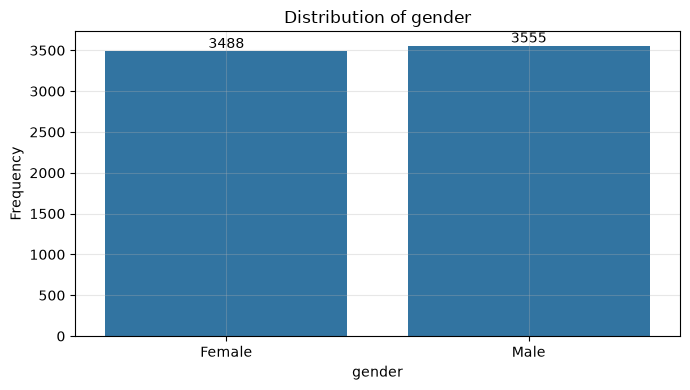

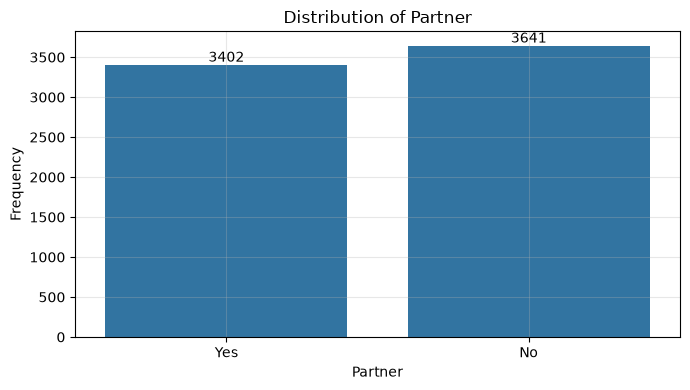

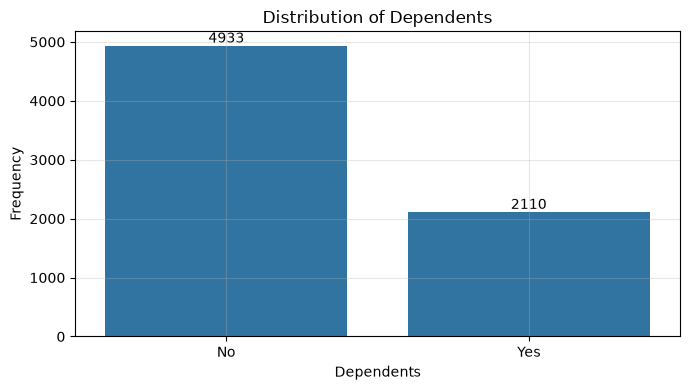

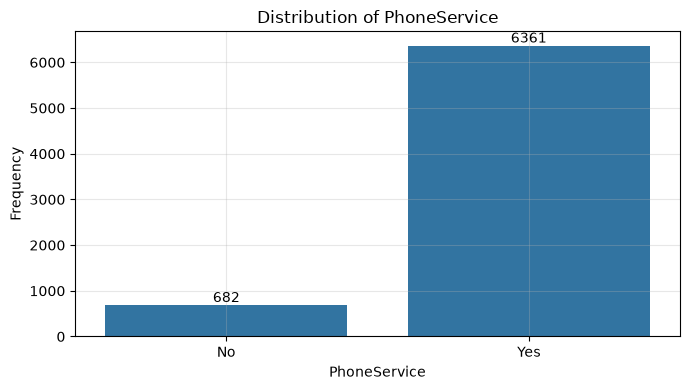

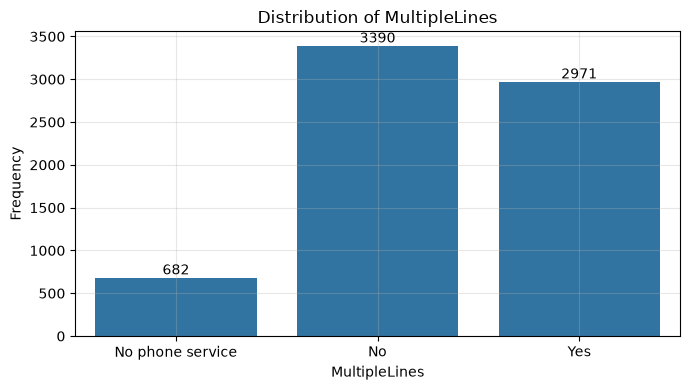

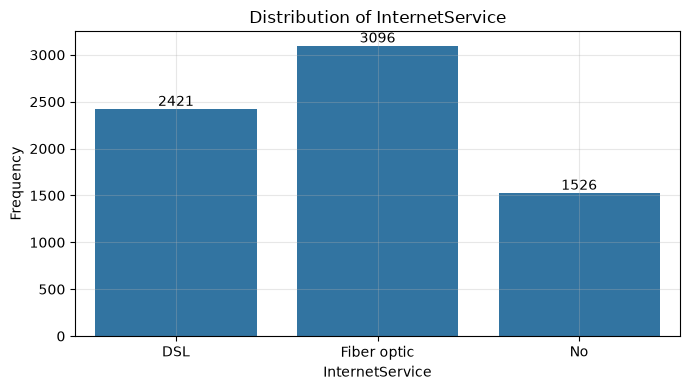

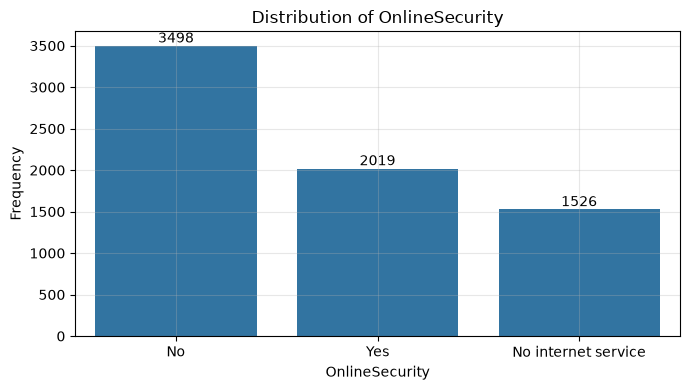

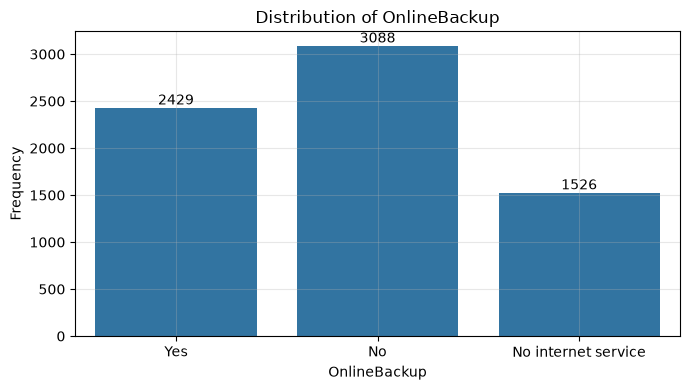

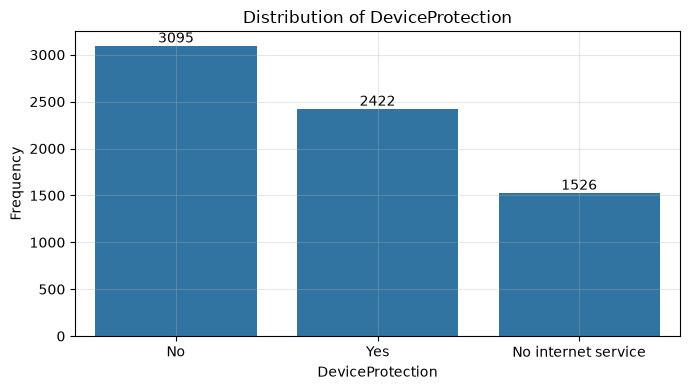

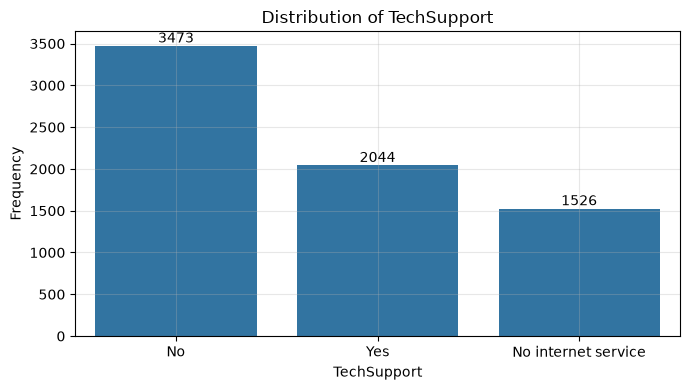

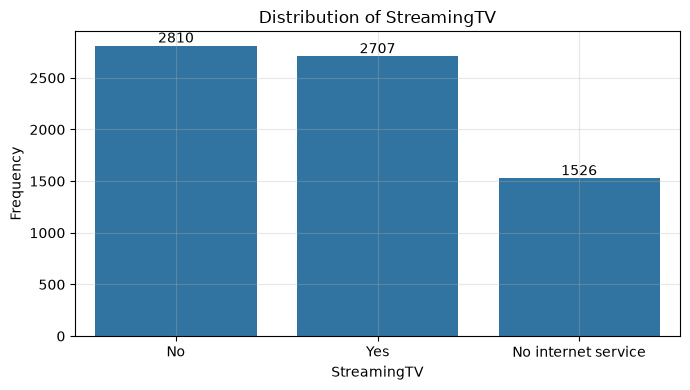

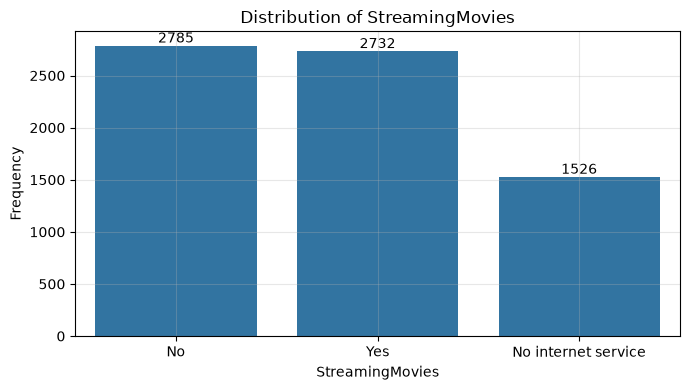

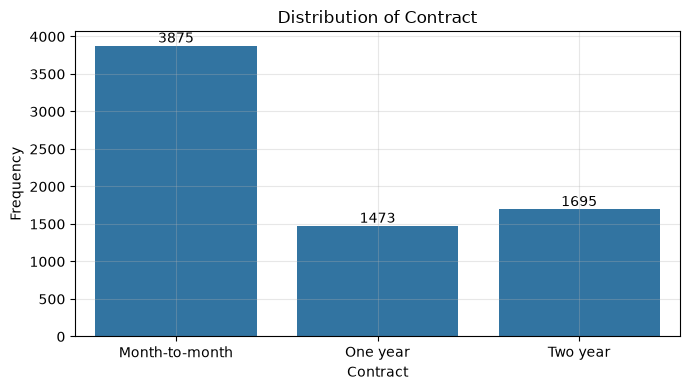

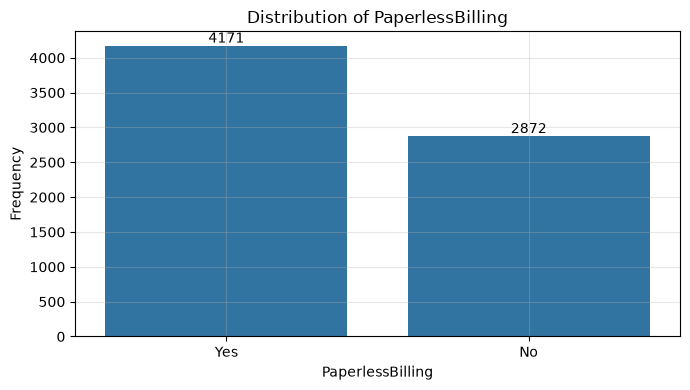

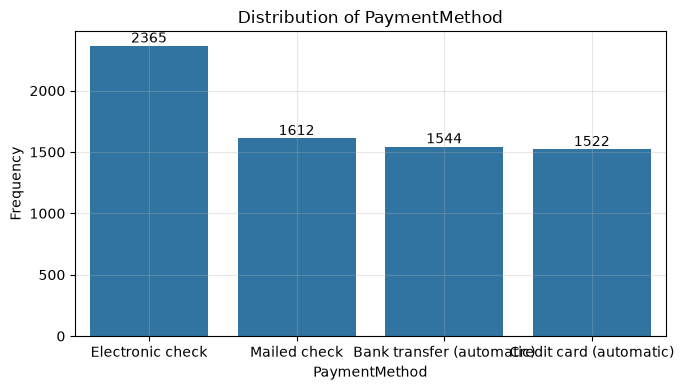

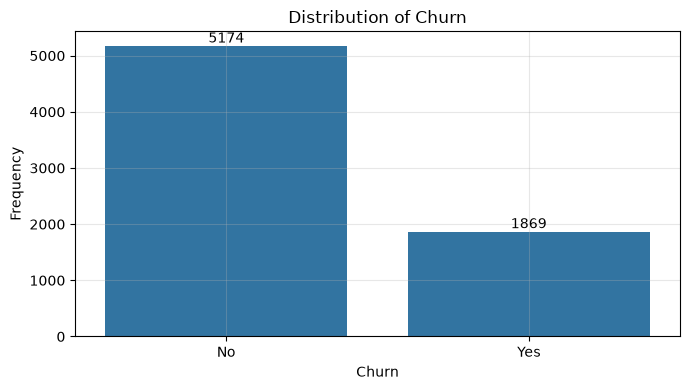

In [57]:
cat_col = df.select_dtypes(include=object).columns.to_list()
for col in cat_col:
    plt.figure(figsize=(7, 4))
    ax = sns.countplot(data=df, x=col)
    for container in ax.containers:
        ax.bar_label(container)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.grid(alpha=0.3)
    plt.show()

In [58]:
#churn by contract

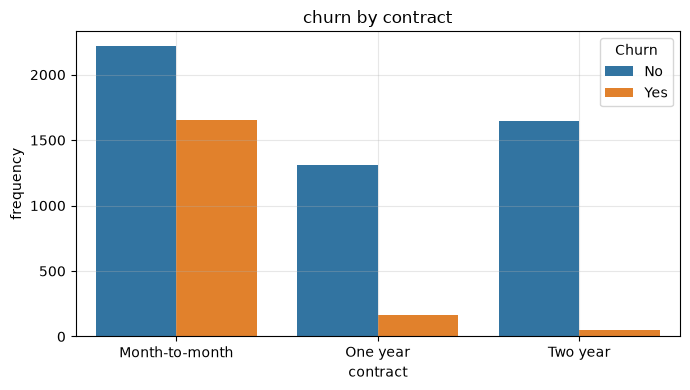

In [59]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.xlabel("contract")
plt.ylabel("frequency")
plt.title("churn by contract")
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()

In [60]:
#churn by payment method

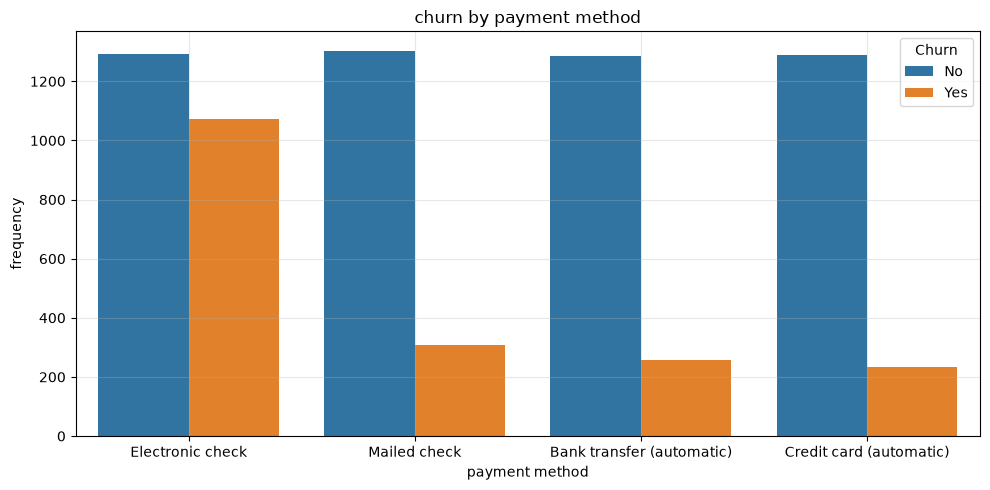

In [61]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.xlabel("payment method")
plt.ylabel("frequency")
plt.title("churn by payment method")
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()

In [62]:
#chrun by internet service

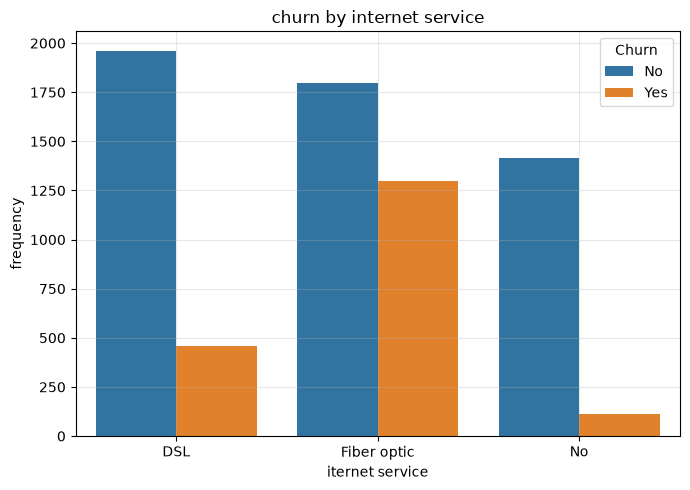

In [63]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.xlabel("iternet service")
plt.ylabel("frequency")
plt.title("churn by internet service")
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()

In [64]:
#chrun by tenure

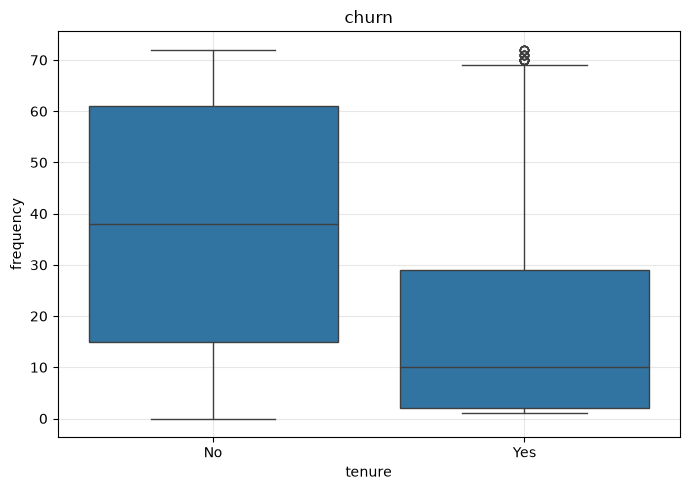

In [65]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, y="tenure", x="Churn")
plt.xlabel("tenure")
plt.ylabel("frequency")
plt.title("churn")
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()

In [66]:
#monthly charges

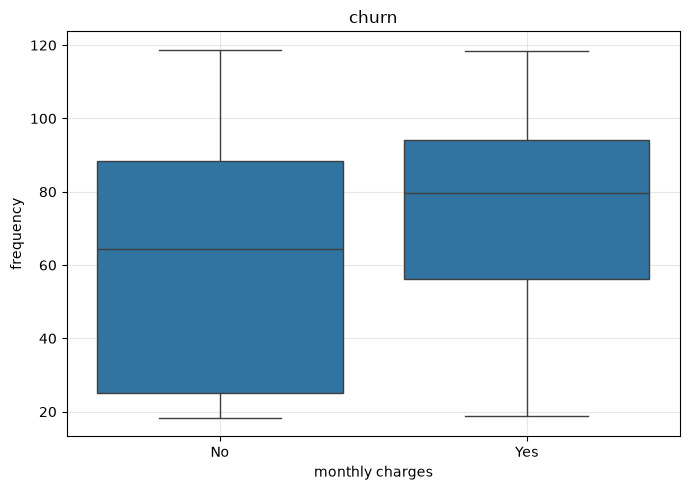

In [67]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, y="MonthlyCharges", x="Churn")
plt.xlabel("monthly charges")
plt.ylabel("frequency")
plt.title("churn")
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()

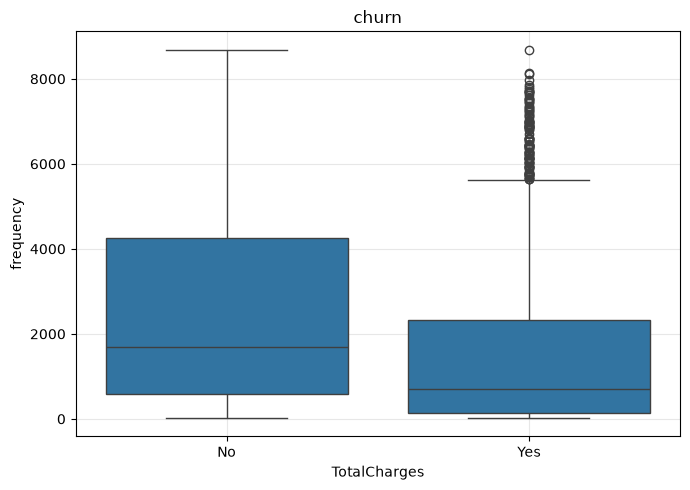

In [71]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, y="TotalCharges", x="Churn")
plt.xlabel("TotalCharges")
plt.ylabel("frequency")
plt.title("churn")
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()

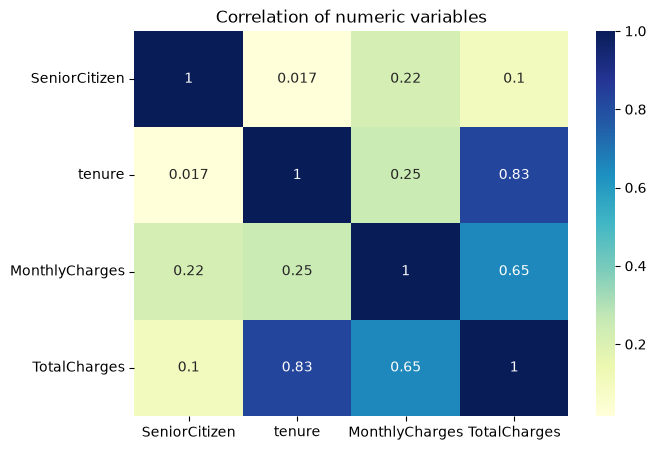

In [68]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(7,5))
sns.heatmap(data=corr_matrix,cmap="YlGnBu",annot=True)
plt.title("Correlation of numeric variables")
plt.show()

In [69]:
segment = pd.crosstab(df['Contract'],df['Churn'],normalize='index') * 100
segment

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


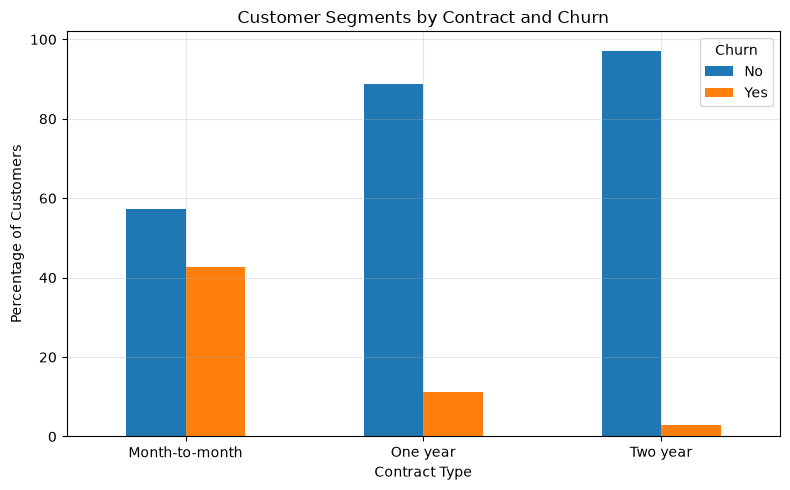

In [70]:
segment.plot(kind='bar', figsize=(8, 5))
plt.title('Customer Segments by Contract and Churn')
plt.xlabel('Contract Type')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()

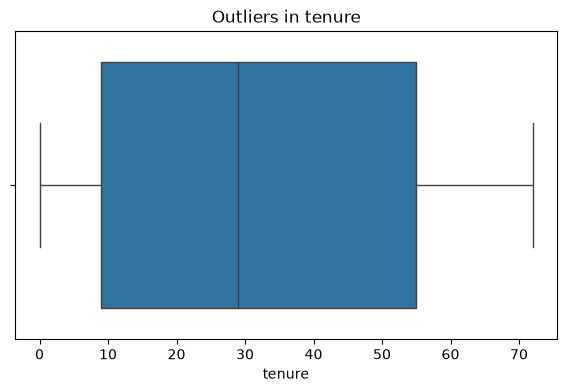

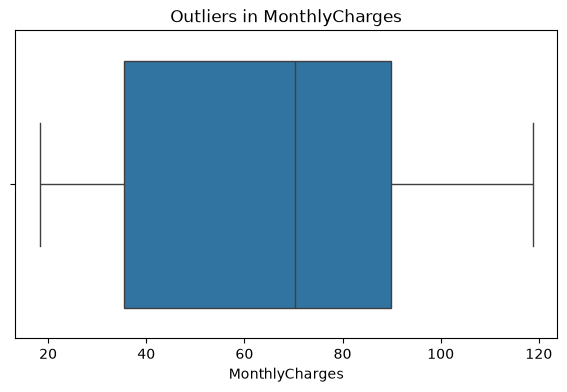

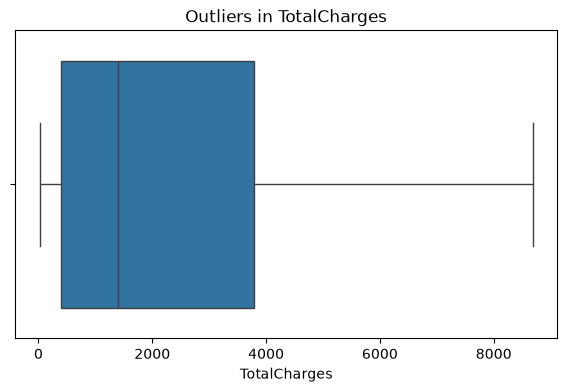

In [72]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numerical_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f'Outliers in {col}')
    plt.xlabel(col)
    plt.show()

In [73]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f'{col}: {len(outliers)} outliers')

tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 0 outliers
